In [1]:
import numpy as np
import matplotlib.pyplot as plt

print("Backpropagation Matematiği")
print("=" * 40)
print()
print("Hedef: Şu soruyu cevaplamak:")
print("'w ağırlığını 0.001 artırırsam,")
print(" loss ne kadar değişir?'")
print()
print("Cevap: dL/dw  (Loss'un w'ye göre türevi)")

Backpropagation Matematiği

Hedef: Şu soruyu cevaplamak:
'w ağırlığını 0.001 artırırsam,
 loss ne kadar değişir?'

Cevap: dL/dw  (Loss'un w'ye göre türevi)


f(x) = x²  →  f'(x) = 2x
x = 3.0
Nümerik türev:   6.000100
Analitik türev:  6.000000
Fark: 0.00010000


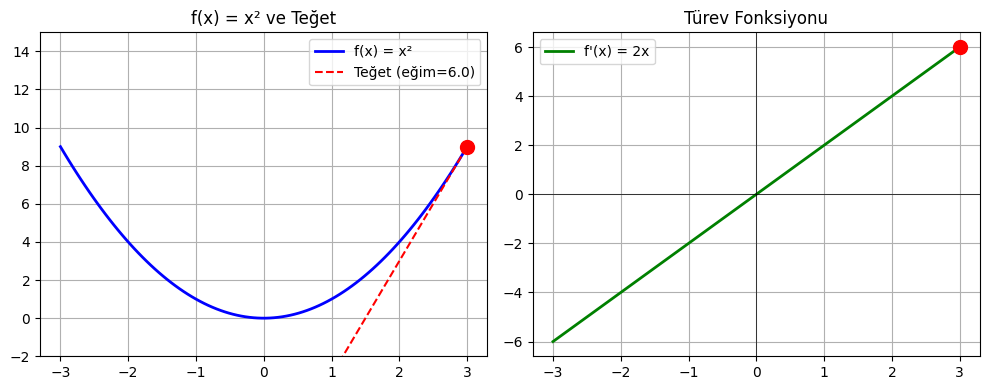

In [2]:
# Türev nedir? Sezgisel anlayış

# Basit bir fonksiyon: f(x) = x²
def f(x):
    return x ** 2

# Türev tanımı: lim(h→0) [f(x+h) - f(x)] / h
def numerik_turev(func, x, h=0.0001):
    return (func(x + h) - func(x)) / h

x = 3.0
turev = numerik_turev(f, x)
analitik = 2 * x  # f'(x) = 2x

print(f"f(x) = x²  →  f'(x) = 2x")
print(f"x = {x}")
print(f"Nümerik türev:   {turev:.6f}")
print(f"Analitik türev:  {analitik:.6f}")
print(f"Fark: {abs(turev - analitik):.8f}")

# Görselleştir
x_range = np.linspace(-3, 3, 100)
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(x_range, f(x_range), 'b-', linewidth=2, label='f(x) = x²')
# Teğet çizgisi x=3'te
tangent = f(x) + analitik * (x_range - x)
plt.plot(x_range, tangent, 'r--', linewidth=1.5, label=f"Teğet (eğim={analitik})")
plt.scatter([x], [f(x)], color='red', s=100, zorder=5)
plt.ylim(-2, 15)
plt.title("f(x) = x² ve Teğet")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(x_range, 2*x_range, 'g-', linewidth=2, label="f'(x) = 2x")
plt.scatter([x], [analitik], color='red', s=100, zorder=5)
plt.title("Türev Fonksiyonu")
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [3]:
# ZİNCİR KURALI
# Eğer y = f(g(x)) ise  →  dy/dx = df/dg * dg/dx
#
# Sinir ağında:
# x → [w1] → z → [sigmoid] → a → [w2] → loss
# dL/dw1 = dL/da * da/dz * dz/dw1

# Somut örnek: tek nöronlu ağ
# z = w * x + b
# a = sigmoid(z)
# L = (a - y)²

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_turev(z):
    s = sigmoid(z)
    return s * (1 - s)  # sigmoid'in türevi: s(1-s)

# İleri besleme
x = 2.0
w = 0.5
b = 0.1
y = 1.0  # hedef

z = w * x + b
a = sigmoid(z)
L = (a - y) ** 2

print("=== İleri Besleme ===")
print(f"x={x}, w={w}, b={b}, y={y}")
print(f"z = w*x + b = {z:.4f}")
print(f"a = sigmoid(z) = {a:.4f}")
print(f"L = (a-y)² = {L:.4f}")

print("\n=== Zincir Kuralı ile Geri Yayılım ===")
# dL/da = 2(a-y)
dL_da = 2 * (a - y)
print(f"dL/da  = 2(a-y) = {dL_da:.4f}")

# da/dz = sigmoid'(z) = s(1-s)
da_dz = sigmoid_turev(z)
print(f"da/dz  = sigmoid'(z) = {da_dz:.4f}")

# dz/dw = x
dz_dw = x
print(f"dz/dw  = x = {dz_dw:.4f}")

# dz/db = 1
dz_db = 1
print(f"dz/db  = 1 = {dz_db:.4f}")

# Zincir kuralı uygula
dL_dw = dL_da * da_dz * dz_dw
dL_db = dL_da * da_dz * dz_db

print(f"\ndL/dw = dL/da * da/dz * dz/dw")
print(f"     = {dL_da:.4f} * {da_dz:.4f} * {dz_dw:.4f}")
print(f"     = {dL_dw:.4f}")

print(f"\ndL/db = dL/da * da/dz * dz/db")
print(f"     = {dL_da:.4f} * {da_dz:.4f} * {dz_db:.4f}")
print(f"     = {dL_db:.4f}")

=== İleri Besleme ===
x=2.0, w=0.5, b=0.1, y=1.0
z = w*x + b = 1.1000
a = sigmoid(z) = 0.7503
L = (a-y)² = 0.0624

=== Zincir Kuralı ile Geri Yayılım ===
dL/da  = 2(a-y) = -0.4995
da/dz  = sigmoid'(z) = 0.1874
dz/dw  = x = 2.0000
dz/db  = 1 = 1.0000

dL/dw = dL/da * da/dz * dz/dw
     = -0.4995 * 0.1874 * 2.0000
     = -0.1872

dL/db = dL/da * da/dz * dz/db
     = -0.4995 * 0.1874 * 1.0000
     = -0.0936


In [4]:
# DOĞRULAMA — Nümerik gradyan ile karşılaştır
def loss_fonk(w, b, x, y):
    z = w * x + b
    a = sigmoid(z)
    return (a - y) ** 2

h = 0.0001

# Nümerik dL/dw
numerik_dL_dw = (loss_fonk(w+h, b, x, y) - loss_fonk(w, b, x, y)) / h

# Nümerik dL/db
numerik_dL_db = (loss_fonk(w, b+h, x, y) - loss_fonk(w, b, x, y)) / h

print("=== Doğrulama ===")
print(f"{'':20s} {'Analitik':>12s} {'Nümerik':>12s} {'Fark':>12s}")
print("-" * 58)
print(f"{'dL/dw':20s} {dL_dw:>12.6f} {numerik_dL_dw:>12.6f} {abs(dL_dw-numerik_dL_dw):>12.8f}")
print(f"{'dL/db':20s} {dL_db:>12.6f} {numerik_dL_db:>12.6f} {abs(dL_db-numerik_dL_db):>12.8f}")

print("\n✅ Fark neredeyse sıfır — zincir kuralı doğru!")

# Görselleştir — gradyan inişi
print("\n=== Gradyan İnişi Simülasyonu ===")
w_sim = 0.1  # farklı başlangıç
b_sim = 0.0
lr = 0.5

print(f"{'Adım':>5s} {'w':>8s} {'b':>8s} {'Loss':>10s} {'dL/dw':>10s}")
print("-" * 45)

for step in range(10):
    # İleri besleme
    z_sim = w_sim * x + b_sim
    a_sim = sigmoid(z_sim)
    L_sim = (a_sim - y) ** 2

    # Geri yayılım
    dL_da_sim = 2 * (a_sim - y)
    da_dz_sim = sigmoid_turev(z_sim)
    dL_dw_sim = dL_da_sim * da_dz_sim * x
    dL_db_sim = dL_da_sim * da_dz_sim * 1

    print(f"{step:>5d} {w_sim:>8.4f} {b_sim:>8.4f} {L_sim:>10.6f} {dL_dw_sim:>10.6f}")

    # Ağırlık güncelle
    w_sim -= lr * dL_dw_sim
    b_sim -= lr * dL_db_sim

=== Doğrulama ===
                         Analitik      Nümerik         Fark
----------------------------------------------------------
dL/dw                   -0.187175    -0.187152   0.00002341
dL/db                   -0.093587    -0.093582   0.00000585

✅ Fark neredeyse sıfır — zincir kuralı doğru!

=== Gradyan İnişi Simülasyonu ===
 Adım        w        b       Loss      dL/dw
---------------------------------------------
    0   0.1000   0.0000   0.202649  -0.445694
    1   0.3228   0.1114   0.101935  -0.277559
    2   0.4616   0.1808   0.061990  -0.186224
    3   0.5547   0.2274   0.043276  -0.137094
    4   0.6233   0.2616   0.032835  -0.107540
    5   0.6771   0.2885   0.026278  -0.088074
    6   0.7211   0.3105   0.021816  -0.074375
    7   0.7583   0.3291   0.018599  -0.064250
    8   0.7904   0.3452   0.016178  -0.056481
    9   0.8186   0.3593   0.014294  -0.050341


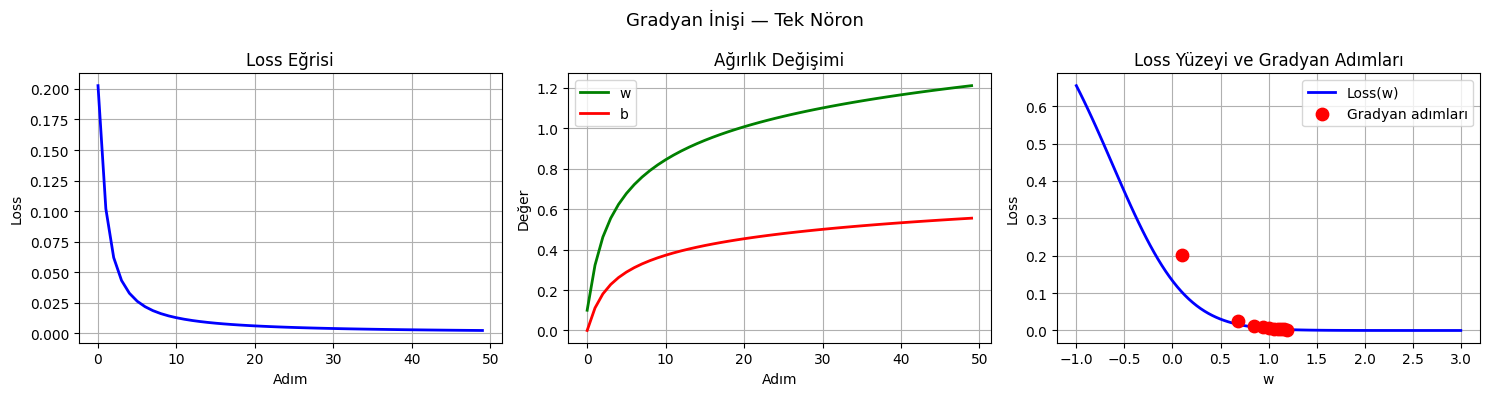


Son değerler:
w = 1.2099
b = 0.5550
Loss = 0.002360
Tahmin = 0.9514 (hedef: 1.0)


In [5]:
# Gradyan inişini görselleştir
w_sim = 0.1
b_sim = 0.0
lr = 0.5

w_history, b_history, loss_history = [], [], []

for step in range(50):
    z_sim = w_sim * x + b_sim
    a_sim = sigmoid(z_sim)
    L_sim = (a_sim - y) ** 2

    dL_da_sim = 2 * (a_sim - y)
    da_dz_sim = sigmoid_turev(z_sim)
    dL_dw_sim = dL_da_sim * da_dz_sim * x
    dL_db_sim = dL_da_sim * da_dz_sim * 1

    w_history.append(w_sim)
    b_history.append(b_sim)
    loss_history.append(L_sim)

    w_sim -= lr * dL_dw_sim
    b_sim -= lr * dL_db_sim

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss eğrisi
axes[0].plot(loss_history, 'b-', linewidth=2)
axes[0].set_title("Loss Eğrisi")
axes[0].set_xlabel("Adım")
axes[0].set_ylabel("Loss")
axes[0].grid(True)

# w değişimi
axes[1].plot(w_history, 'g-', linewidth=2, label='w')
axes[1].plot(b_history, 'r-', linewidth=2, label='b')
axes[1].set_title("Ağırlık Değişimi")
axes[1].set_xlabel("Adım")
axes[1].set_ylabel("Değer")
axes[1].legend()
axes[1].grid(True)

# Loss yüzeyi — w'ye göre
w_range = np.linspace(-1, 3, 100)
losses = [loss_fonk(w_val, b_history[-1], x, y) for w_val in w_range]
axes[2].plot(w_range, losses, 'b-', linewidth=2, label='Loss(w)')
axes[2].scatter(w_history[::5], 
                [loss_fonk(w_val, b_history[i*5], x, y) 
                 for i, w_val in enumerate(w_history[::5])],
                color='red', s=80, zorder=5, label='Gradyan adımları')
axes[2].set_title("Loss Yüzeyi ve Gradyan Adımları")
axes[2].set_xlabel("w")
axes[2].set_ylabel("Loss")
axes[2].legend()
axes[2].grid(True)

plt.suptitle("Gradyan İnişi — Tek Nöron", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nSon değerler:")
print(f"w = {w_history[-1]:.4f}")
print(f"b = {b_history[-1]:.4f}")
print(f"Loss = {loss_history[-1]:.6f}")
print(f"Tahmin = {sigmoid(w_history[-1]*x + b_history[-1]):.4f} (hedef: {y})")

In [6]:
# 2 KATMANLI AĞ — ELLE BACKPROP
# Mimari: x → [W1,b1] → z1 → [ReLU] → a1 → [W2,b2] → z2 → [sigmoid] → a2 → Loss
#
# İleri besleme:
# z1 = W1*x + b1
# a1 = ReLU(z1)
# z2 = W2*a1 + b2
# a2 = sigmoid(z2)
# L  = -(y*log(a2) + (1-y)*log(1-a2))  ← Binary Cross Entropy

def relu(z):
    return np.maximum(0, z)

def relu_turev(z):
    return (z > 0).astype(float)

def bce_loss(a, y, eps=1e-8):
    return -(y * np.log(a + eps) + (1-y) * np.log(1-a + eps))

# Başlangıç değerleri
np.random.seed(42)
x  = np.array([0.5, 0.8])   # 2 özellik
y  = 1.0                     # hedef

W1 = np.array([[0.3, -0.2],
               [0.1,  0.4],
               [-0.3, 0.5]])  # (3, 2)
b1 = np.zeros(3)              # (3,)
W2 = np.array([0.6, -0.4, 0.2])  # (3,)
b2 = 0.1                     # scalar

print("=== İLERİ BESLEME ===")
z1 = W1 @ x + b1
print(f"z1 = W1@x + b1 = {z1.round(4)}")

a1 = relu(z1)
print(f"a1 = ReLU(z1)  = {a1.round(4)}")

z2 = W2 @ a1 + b2
print(f"z2 = W2@a1 + b2 = {z2:.4f}")

a2 = sigmoid(z2)
print(f"a2 = sigmoid(z2) = {a2:.4f}")

L = bce_loss(a2, y)
print(f"L  = BCE(a2, y)  = {L:.4f}")

print("\n=== GERİ YAYILIM (Zincir Kuralı) ===")

# Katman 2 gradyanları
dL_da2 = -(y/a2 - (1-y)/(1-a2))
print(f"\ndL/da2 = {dL_da2:.4f}")

da2_dz2 = sigmoid_turev(z2)
print(f"da2/dz2 = sigmoid'(z2) = {da2_dz2:.4f}")

dL_dz2 = dL_da2 * da2_dz2
print(f"dL/dz2 = dL/da2 * da2/dz2 = {dL_dz2:.4f}")

dL_dW2 = dL_dz2 * a1
dL_db2 = dL_dz2
print(f"dL/dW2 = dL/dz2 * a1 = {dL_dW2.round(4)}")
print(f"dL/db2 = dL/dz2      = {dL_db2:.4f}")

# Katman 1 gradyanları
dL_da1 = dL_dz2 * W2
print(f"\ndL/da1 = dL/dz2 * W2 = {dL_da1.round(4)}")

da1_dz1 = relu_turev(z1)
print(f"da1/dz1 = ReLU'(z1)  = {da1_dz1}")

dL_dz1 = dL_da1 * da1_dz1
print(f"dL/dz1 = dL/da1 * da1/dz1 = {dL_dz1.round(4)}")

dL_dW1 = np.outer(dL_dz1, x)
dL_db1 = dL_dz1
print(f"dL/dW1 =\n{dL_dW1.round(4)}")
print(f"dL/db1 = {dL_db1.round(4)}")

=== İLERİ BESLEME ===
z1 = W1@x + b1 = [-0.01  0.37  0.25]
a1 = ReLU(z1)  = [0.   0.37 0.25]
z2 = W2@a1 + b2 = 0.0020
a2 = sigmoid(z2) = 0.5005
L  = BCE(a2, y)  = 0.6921

=== GERİ YAYILIM (Zincir Kuralı) ===

dL/da2 = -1.9980
da2/dz2 = sigmoid'(z2) = 0.2500
dL/dz2 = dL/da2 * da2/dz2 = -0.4995
dL/dW2 = dL/dz2 * a1 = [-0.     -0.1848 -0.1249]
dL/db2 = dL/dz2      = -0.4995

dL/da1 = dL/dz2 * W2 = [-0.2997  0.1998 -0.0999]
da1/dz1 = ReLU'(z1)  = [0. 1. 1.]
dL/dz1 = dL/da1 * da1/dz1 = [-0.      0.1998 -0.0999]
dL/dW1 =
[[-0.     -0.    ]
 [ 0.0999  0.1598]
 [-0.05   -0.0799]]
dL/db1 = [-0.      0.1998 -0.0999]


In [7]:
import torch

# Aynı değerleri PyTorch ile hesapla
x_t  = torch.tensor([0.5, 0.8], dtype=torch.float32)
y_t  = torch.tensor(1.0, dtype=torch.float32)

W1_t = torch.tensor([[0.3, -0.2],
                      [0.1,  0.4],
                      [-0.3, 0.5]], dtype=torch.float32, requires_grad=True)
b1_t = torch.zeros(3, requires_grad=True)
W2_t = torch.tensor([0.6, -0.4, 0.2], dtype=torch.float32, requires_grad=True)
b2_t = torch.tensor(0.1, dtype=torch.float32, requires_grad=True)

# İleri besleme
z1_t = W1_t @ x_t + b1_t
a1_t = torch.relu(z1_t)
z2_t = W2_t @ a1_t + b2_t
a2_t = torch.sigmoid(z2_t)
L_t  = -(y_t * torch.log(a2_t) + (1-y_t) * torch.log(1-a2_t))

# Otomatik backprop
L_t.backward()

print("=== PYTORCH AUTOGRAD vs ELLE HESAPLAMA ===")
print(f"\n{'':15s} {'Elle':>15s} {'PyTorch':>15s} {'Fark':>12s}")
print("-" * 60)

karşılaştır = [
    ("dL/dW2[0]", dL_dW2[0], W2_t.grad[0].item()),
    ("dL/dW2[1]", dL_dW2[1], W2_t.grad[1].item()),
    ("dL/dW2[2]", dL_dW2[2], W2_t.grad[2].item()),
    ("dL/db2",    dL_db2,    b2_t.grad.item()),
    ("dL/dW1[0,0]", dL_dW1[0,0], W1_t.grad[0,0].item()),
    ("dL/dW1[1,0]", dL_dW1[1,0], W1_t.grad[1,0].item()),
    ("dL/dW1[2,1]", dL_dW1[2,1], W1_t.grad[2,1].item()),
    ("dL/db1[1]", dL_db1[1], b1_t.grad[1].item()),
]

for isim, elle, pytorch in karşılaştır:
    fark = abs(elle - pytorch)
    print(f"{isim:15s} {elle:>15.6f} {pytorch:>15.6f} {fark:>12.8f}")

print("\n✅ Farklar neredeyse sıfır!")
print("PyTorch'un autograd'ı tam olarak zincir kuralını uyguluyor.")

=== PYTORCH AUTOGRAD vs ELLE HESAPLAMA ===

                           Elle         PyTorch         Fark
------------------------------------------------------------
dL/dW2[0]             -0.000000       -0.000000   0.00000000
dL/dW2[1]             -0.184815       -0.184815   0.00000003
dL/dW2[2]             -0.124875       -0.124875   0.00000001
dL/db2                -0.499500       -0.499500   0.00000004
dL/dW1[0,0]           -0.000000        0.000000   0.00000000
dL/dW1[1,0]            0.099900        0.099900   0.00000001
dL/dW1[2,1]           -0.079920       -0.079920   0.00000001
dL/db1[1]              0.199800        0.199800   0.00000001

✅ Farklar neredeyse sıfır!
PyTorch'un autograd'ı tam olarak zincir kuralını uyguluyor.


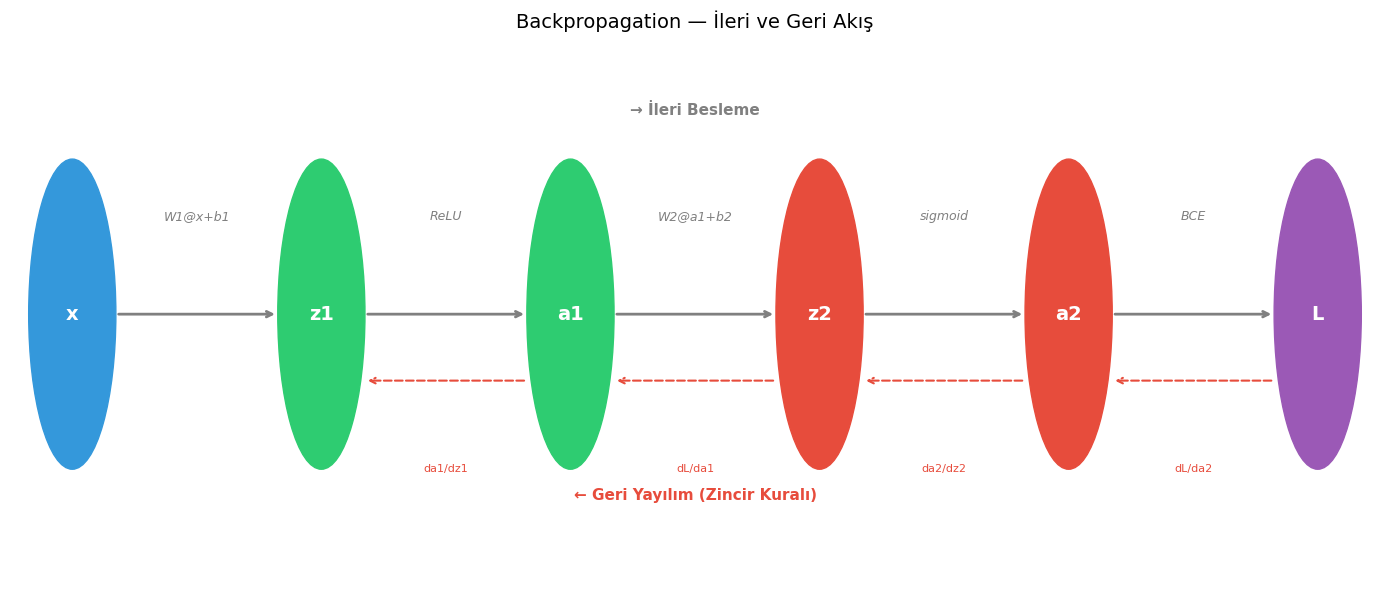

In [8]:
# ÖZET — Backprop Akış Diyagramı
fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')

# Düğümler
düğümler = {
    'x':  (0.5, 0.5),
    'z1': (2.5, 0.5),
    'a1': (4.5, 0.5),
    'z2': (6.5, 0.5),
    'a2': (8.5, 0.5),
    'L':  (10.5, 0.5),
}

renkler = {
    'x': '#3498db', 'z1': '#2ecc71', 'a1': '#2ecc71',
    'z2': '#e74c3c', 'a2': '#e74c3c', 'L': '#9b59b6'
}

for isim, (px, py) in düğümler.items():
    circle = plt.Circle((px, py), 0.35, color=renkler[isim], zorder=5)
    ax.add_patch(circle)
    ax.text(px, py, isim, ha='center', va='center',
            fontsize=14, fontweight='bold', color='white', zorder=6)

# İleri ok
oklar = [('x','z1'), ('z1','a1'), ('a1','z2'), ('z2','a2'), ('a2','L')]
for (a, b) in oklar:
    x1, y1 = düğümler[a]
    x2, y2 = düğümler[b]
    ax.annotate('', xy=(x2-0.35, y2), xytext=(x1+0.35, y1),
                arrowprops=dict(arrowstyle='->', color='gray', lw=2))

# İleri besleme etiketleri
etiketler_ileri = ['W1@x+b1', 'ReLU', 'W2@a1+b2', 'sigmoid', 'BCE']
pozisyonlar = [(1.5, 0.72), (3.5, 0.72), (5.5, 0.72), (7.5, 0.72), (9.5, 0.72)]
for etiket, (px, py) in zip(etiketler_ileri, pozisyonlar):
    ax.text(px, py, etiket, ha='center', va='center',
            fontsize=9, color='gray', style='italic')

# Geri yayılım okları
geri_oklar = [('L','a2'), ('a2','z2'), ('z2','a1'), ('a1','z1')]
geri_etiketler = ['dL/da2', 'da2/dz2', 'dL/da1', 'da1/dz1']
for (a, b), etiket in zip(geri_oklar, geri_etiketler):
    x1, y1 = düğümler[a]
    x2, y2 = düğümler[b]
    ax.annotate('', xy=(x2+0.35, y2-0.15), xytext=(x1-0.35, y1-0.15),
                arrowprops=dict(arrowstyle='->', color='#e74c3c',
                               lw=1.5, linestyle='dashed'))
    mx = (x1 + x2) / 2
    ax.text(mx, y1-0.35, etiket, ha='center', va='center',
            fontsize=8, color='#e74c3c')

ax.text(5.5, 0.95, '→ İleri Besleme', ha='center', fontsize=11,
        color='gray', fontweight='bold')
ax.text(5.5, 0.08, '← Geri Yayılım (Zincir Kuralı)', ha='center',
        fontsize=11, color='#e74c3c', fontweight='bold')

ax.set_xlim(0, 11)
ax.set_ylim(-0.1, 1.1)
plt.title("Backpropagation — İleri ve Geri Akış", fontsize=14, pad=15)
plt.tight_layout()
plt.show()